![Py4Eng](../logo.png)

# Animal Re-Identification
## Yoav Ram

In this session we will understand:
- that **re-identification is metric learning where the assumption fails hardest**: not 200 species but
  400 *individuals*, most of them photographed a handful of times, and new ones arriving forever
- that **how you split the data is a claim about what you measured** — a random split and a time-aware
  split of the same photographs, with the same model, differ by more than any architecture in this course
- that "how good is this embedding" is **three different questions** — ranking, rejection and clustering —
  with three different answers, and that reporting one and implying the others is the standard way to
  mislead yourself
- how to build a **normalized cosine head with an angular margin** in `keras.ops`, and extend it with
  **sub-centers** and a **per-individual margin** for the long tail
- why **global embeddings and local descriptors have different inductive biases**, and why the deployed
  answer is a hybrid rather than a winner

This session is the companion to [Open-Set Metric Learning](metric_learning.ipynb) and assumes it: the
open/closed class split, Recall@K, mAP@R, the stopping-epoch argument and the
choose-on-held-out-classes discipline all come from there and are not re-derived here. What that session
promised twice — the angular margin, and sub-centers for the long tail — is built here.

The shift is from **species to individuals**. A model that tells a loggerhead turtle from a green turtle
has learned what the species look like. A model that tells *this* loggerhead from *that* one has to
ignore everything the two share, which is almost everything, and key on a scale pattern behind the eye.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

import jax
import keras
from keras import ops
print('Keras:', keras.__version__, 'backend:', keras.backend.backend(), jax.default_backend())

SEED = 23
keras.utils.set_random_seed(SEED)
sns.set(style='white', context='talk')
DATA = Path('../data')

Keras: 3.15.1 backend: jax cpu


The same two helpers as the companion session. `normalize` projects rows onto the unit sphere, so that
an inner product *is* a cosine similarity; every score in this notebook is computed on normalized
embeddings, and nothing below means anything without that.

In [2]:
def normalize(V):
    """Project rows onto the unit sphere, so that inner product is cosine similarity."""
    V = np.asarray(V, dtype='float32')
    return V / np.maximum(np.linalg.norm(V, axis=1, keepdims=True), 1e-12)


def plot_history(history, title=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

    ax = axes[0]
    ax.plot(history['sparse_categorical_accuracy'], label='Train')
    ax.set(ylabel='Closed-set accuracy', xlabel='Epochs')
    ax.legend()

    ax = axes[1]
    ax.plot(history['loss'], label='Train')
    ax.set(ylabel='Loss', xlabel='Epochs')
    ax.legend()

    if title:
        fig.suptitle(title)
    fig.tight_layout()

# The data: 400 loggerhead turtles, photographed for twelve years

[SeaTurtleID2022](https://openaccess.thecvf.com/content/WACV2024/html/Adam_SeaTurtleID2022_A_Long-Span_Dataset_for_Reliable_Sea_Turtle_Re-Identification_WACV_2024_paper.html)
is a photo-identification archive of loggerhead sea turtles from Zakynthos, Greece, collected between
2010 and 2021 by divers who photographed whichever turtle they met. We use `SeaTurtleIDHeads`, the
head-crop version: 7,582 crops of 400 individuals.

We fetch it with the [`wildlife-datasets`](https://github.com/WildlifeDatasets/wildlife-datasets)
package, which is the reference loader for this whole family of re-identification datasets and, usefully
for us, also implements the splitting protocols their papers define. It needs a Kaggle API token —
`python download_data.py --list` says how — and the catalogue and cached arrays are built once by
`scripts/reid_data.py`.

Three columns matter and only one of them is the label:

- `identity` — which turtle. 400 of them.
- `date` — when the photograph was taken. This is the column that makes an honest evaluation possible,
  and most re-identification datasets do not have it.
- `orientation` — which side of the head faces the camera.

In [3]:
turtles = pd.read_csv(DATA / 'turtle_catalogue.csv')
images = np.load(DATA / 'turtle_images_224.npy', mmap_mode='r')

print('{:,} head crops of {} individuals, {} to {}'.format(
    len(turtles), turtles.identity.nunique(), turtles.date.min(), turtles.date.max()))
turtles.head()

7,582 head crops of 400 individuals, 2010-07-02 to 2021-09-14


,image_id,identity,path,date,orientation,role,arm_time,arm_random
0,0,t001,images/t001/IxRLFwTGCv.JPG,2010-07-02,topright,tune,database,database
1,1,t001,images/t001/VMyJozldvy.jpg,2010-07-02,topright,tune,database,query
2,2,t001,images/t001/XhbkFIOvZr.JPG,2010-07-02,topright,tune,database,database
3,3,t001,images/t001/ZKnMahXQgJ.JPG,2010-07-02,top,tune,database,database
4,4,t001,images/t001/ZkWKNtWbVK.JPG,2010-07-02,topleft,tune,database,database


## The long tail is the point, not a nuisance

Count the photographs per individual and the shape of the problem appears. A few turtles were met
constantly; most were met once or twice. This is not a flaw in the dataset — it is what wildlife data
*is*, and any method that needs fifty images per class to work has already failed here.

median 13 photographs per individual, max 182
174 of 400 individuals have 10 or fewer
172 were photographed on a single day


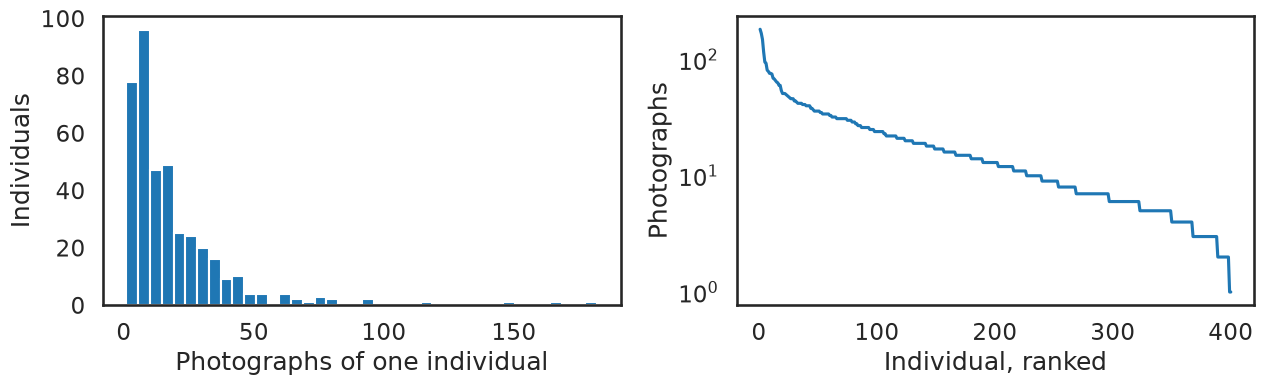

In [4]:
counts = turtles.identity.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
ax.hist(counts.to_numpy(), bins=40, color='tab:blue')
ax.set(xlabel='Photographs of one individual', ylabel='Individuals')

ax = axes[1]
ax.plot(np.arange(1, len(counts) + 1), counts.to_numpy(), color='tab:blue')
ax.set(xlabel='Individual, ranked', ylabel='Photographs', yscale='log')
fig.tight_layout()

print('median {:.0f} photographs per individual, max {}'.format(counts.median(), counts.max()))
print('{} of {} individuals have 10 or fewer'.format((counts <= 10).sum(), len(counts)))
print('{} were photographed on a single day'.format(
    (turtles.groupby("identity").date.nunique() == 1).sum()))

Here are four individuals, three photographs each. Look at what varies *within* a row — the turtle is
the same animal in every frame, at a different angle, in different water, years apart — and at what
distinguishes one row from another. The usable signal is the arrangement of scales on the cheek, and it
is a small part of each image.

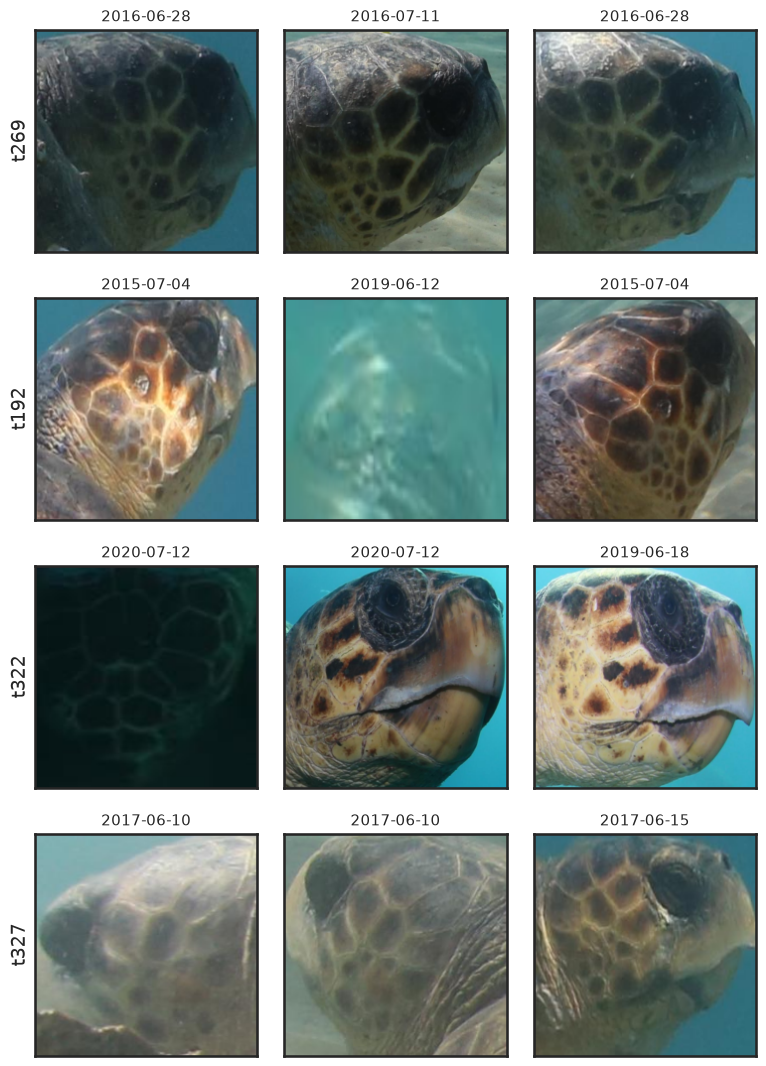

In [5]:
rng = np.random.default_rng(SEED)
picked = rng.choice(counts.index[counts >= 6].to_numpy(), size=4, replace=False)

fig, axes = plt.subplots(4, 3, figsize=(8, 11))
for row, identity in enumerate(picked):
    rows = turtles.index[turtles.identity == identity].to_numpy()
    for col, idx in enumerate(rng.choice(rows, size=3, replace=False)):
        ax = axes[row, col]
        ax.imshow(images[idx])
        ax.set(xticks=[], yticks=[])
        if col == 0:
            ax.set_ylabel(identity, fontsize=14)
        ax.set_title(turtles.date[idx], fontsize=11)
fig.tight_layout()

## The crop is doing work, and it is invisible

These are **head crops**, not photographs. Somebody — a detector, or a person with a mouse — found the
head in a much larger underwater frame and cut it out, and that step removed most of the pose variation,
most of the background and most of the scale variation before we ever saw the data.

This matters because it is easy to conclude from a notebook like this one that global embeddings are
robust to pose. They are not especially robust to pose; the **cropper** was. When the same pipeline is
pointed at uncropped field photographs it performs far worse, and the missing component is not the
embedding model. Whenever you read a re-identification number, ask what arrived pre-cropped.

# How you split the data is a claim about what you measured

This is the most important section in the session, and it has nothing to do with neural networks.

A diver meets a turtle and takes eleven photographs of it over two minutes. Same animal, same water,
same light, same angle of the sun, same speck of algae on its shell. If you now shuffle all the
photographs in the archive and deal them into a training set and a test set, those eleven pictures are
dealt into *both*. At test time the model is shown one of them and asked to find the same turtle in the
database — where ten near-duplicates of the query are waiting.

It will find them. It would find them if it had learned nothing about turtles at all, because what it is
actually matching is the **encounter**: the water, the light, the algae. The number you report is real,
reproducible, and measures something you do not want.

`SeaTurtleID2022` was built to expose exactly this, which is why it ships dates. The fix is to split by
**time**: the database holds the earlier encounters, the query set holds the later ones, and no
photograph is ever matched against another from its own day.

## Two arms that differ in exactly one thing

`scripts/reid_data.py` builds both. For each individual, the time-aware rule (Čermák et al.,
[arXiv:2211.10307](https://arxiv.org/abs/2211.10307), as implemented by
`wildlife_datasets.splits.TimeProportionSplit`) sends the later half of its observation *dates* to the
query set. The random rule then draws **the same number** of query images per individual, at random.

Matching the counts per individual is deliberate and worth being pedantic about. Database size, query
size and the label distribution come out identical, so when the two arms disagree the difference cannot
be blamed on any of them. One rule changes, one number changes.

In [6]:
def same_day_leak(catalogue, arm):
    # How often a query image has a same-individual, same-day photograph in the database.
    column = f'arm_{arm}'
    database = catalogue[catalogue[column] == 'database']
    seen = set(zip(database.identity, database.date))
    # Unknown individuals are absent from the database by construction, so counting
    # them here would only dilute the number this is about.
    query = catalogue[(catalogue[column] == 'query') & (catalogue.role != 'unknown')]
    return np.mean([(i, d) in seen for i, d in zip(query.identity, query.date)])


summary = pd.DataFrame({
    arm: {
        'database': (turtles[f'arm_{arm}'] == 'database').sum(),
        'query': (turtles[f'arm_{arm}'] == 'query').sum(),
        'same-day leak': '{:.1%}'.format(same_day_leak(turtles, arm)),
    }
    for arm in ('random', 'time')
})
summary

,random,time
database,3838,3838
query,3744,3744
same-day leak,94.7%,0.0%


**95% against 0%.** Under the random split, almost every query image has a photograph of the same turtle
taken on the same day sitting in the database it is searching. Under the time-aware split, by
construction, none do. The two arms hold the same photographs of the same turtles in the same numbers;
they disagree only about which side of the wall each photograph is on.

Everything reported below is reported twice, once per arm, for this reason.

## What the honest split costs

An honest protocol is not free, and the bill is worth seeing. An individual photographed on only one
day cannot contribute a query image to the time-aware arm at all — there is no "later" encounter to ask
about — so it contributes none to either arm, and 172 of our 400 individuals are in that position. The
time-aware split is not merely a harder version of the random split. It is a *smaller* one, and it
discards the tail of the distribution first.

In [7]:
dates_per_identity = turtles.groupby('identity').date.nunique()
contributes = turtles[turtles.arm_time == 'query'].identity.nunique()

print('{} of {} individuals were photographed on a single day'.format(
    (dates_per_identity == 1).sum(), len(dates_per_identity)))
print('{} individuals contribute a query image; the other {} can only sit in the database'.format(
    contributes, turtles.identity.nunique() - contributes))

172 of 400 individuals were photographed on a single day
252 individuals contribute a query image; the other 148 can only sit in the database


## Who is in the database, and who is not

The three roles are fixed once, in `scripts/reid_data.py`, and used by every arm and every model:

| role | individuals | in the database? | trained on? | what it is for |
|---|---|---|---|---|
| `train` | 300 | yes | yes | the identities the model is fitted on and reported on |
| `tune` | 50 | yes | **no** | every threshold, every epoch budget, every linkage choice |
| `unknown` | 50 | **no** | **no** | the open-set queries that should be *rejected*, and the individuals the clustering metric must recover |

The `tune` individuals are the companion session's discipline carried over intact: choose
hyperparameters on held-out *classes*, never on the ones you report. In this session that discipline
does more work than usual, because we are about to discover that some of the numbers below are mostly
measuring a hyperparameter.

In [8]:
roles = turtles.groupby('role').agg(individuals=('identity', 'nunique'), images=('identity', 'size'))
roles.loc[['train', 'tune', 'unknown']]

,individuals,images
role,,
train,300,5849
tune,50,1029
unknown,50,704


# Warm start: ask CLIP who this is

The companion session ended with CLIP classifying a hundred bird species it had never been trained on,
by writing its class proxies down in English instead of fitting them. That is a genuinely remarkable
result, and the obvious question is whether it solves this problem too.

The embeddings are already cached, so the experiment costs nothing. We load CLIP the same way the
companion session does — `keras-hub` installed without its dependency tree, with the tokenizer patch
that session explains — and use it twice: once to name the **species**, once to name the
**individual**.

In [9]:
from keras_hub.layers import CLIPImageConverter
from keras_hub.models import CLIPBackbone, CLIPTokenizer

CLIP_PRESET = 'clip_vit_base_patch16'

# keras-hub 0.32 only assigns `vocabulary` and `merges` in its TensorFlow code path,
# which we do not install; the pure-Python path then reads them back as None. See
# metric_learning.ipynb, where this patch is explained.
_set_vocabulary_and_merges = CLIPTokenizer._set_vocabulary_and_merges_tokenizers

def _set_vocabulary_and_merges_without_tensorflow(self, vocabulary, merges):
    self.vocabulary = vocabulary.copy()
    self.merges = list(merges)
    return _set_vocabulary_and_merges(self, vocabulary, merges)

CLIPTokenizer._set_vocabulary_and_merges_tokenizers = _set_vocabulary_and_merges_without_tensorflow

clip = CLIPBackbone.from_preset(CLIP_PRESET)
clip_tokenizer = CLIPTokenizer.from_preset(CLIP_PRESET)
CONTEXT_LENGTH = 77


def encode_prompts(prompts):
    '''Turn sentences into unit-length proxies in CLIP's shared image-text space.'''
    token_ids = np.zeros((len(prompts), CONTEXT_LENGTH), dtype='int32')
    for row, tokens in enumerate(clip_tokenizer(prompts)):
        tokens = ([clip_tokenizer.start_token_id]
                  + list(tokens)[:CONTEXT_LENGTH - 2]
                  + [clip_tokenizer.end_token_id])
        token_ids[row, :len(tokens)] = tokens
    return normalize(np.asarray(clip.get_text_embeddings(token_ids)))

## It can name the species

Nine prompts, one of them right, over a thousand turtle photographs.

In [10]:
Z_clip = np.load(DATA / 'turtle_clip_vitb16_images.npy')

species_prompts = [
    'a photo of a loggerhead sea turtle.',
    'a photo of a dolphin.',
    'a photo of a shark.',
    'a photo of a fish.',
    'a photo of a seal.',
    'a photo of a crocodile.',
    'a photo of a rock underwater.',
    'a photo of a dog.',
    'a photo of a car.',
]

sample = rng.choice(len(turtles), size=1000, replace=False)
choice = (Z_clip[sample] @ encode_prompts(species_prompts).T).argmax(axis=1)

pd.Series([species_prompts[i] for i in choice]).value_counts().head()

a photo of a loggerhead sea turtle.    964
a photo of a rock underwater.           11
a photo of a shark.                     10
a photo of a fish.                       6
a photo of a dolphin.                    4
Name: count, dtype: int64

# Scoring: query against database, never against itself

The companion session scored a pooled set leave-one-out, which is right when there is no split to
respect. Here there is. A query image is searched against the **database only**, and the database is
whatever this arm put there — otherwise a time-arm query would quietly be allowed to retrieve its own
encounter-mates, and we would have built the two arms for nothing.

In [11]:
def gallery_scores(query, query_labels, database, database_labels, ks=(1, 5, 10)):
    '''Recall@K and mAP@R for queries searched against a separate database.'''
    similarity = normalize(query) @ normalize(database).T
    order = np.argsort(-similarity, axis=1)
    hits = database_labels[order] == query_labels[:, None]
    scores = {f'recall@{k}': hits[:, :k].any(axis=1).mean() for k in ks}

    # R is how many correct answers exist *in the database* for this query, which is
    # not the same as how many photographs the individual has.
    available = np.bincount(database_labels, minlength=database_labels.max() + 1)
    average_precisions = []
    for row, R in zip(hits, available[query_labels]):
        if R > 0:
            precision = np.cumsum(row[:R]) / np.arange(1, R + 1)
            average_precisions.append((precision * row[:R]).sum() / R)
    scores['mAP@R'] = np.mean(average_precisions)
    return scores


def split_of(embeddings, arm, role='train'):
    '''The query and database halves of one arm, for one role of individual.'''
    rows = turtles[turtles.role == role]
    labels = pd.factorize(rows.identity)[0]
    is_query = (rows[f'arm_{arm}'] == 'query').to_numpy()
    Z = embeddings[rows.index.to_numpy()]
    return Z[is_query], labels[is_query], Z[~is_query], labels[~is_query]


def evaluate(embeddings, arm, role='train'):
    return gallery_scores(*split_of(embeddings, arm, role))

# Baseline 0: the backbone, untouched

Before anything is trained, the mandatory baseline from the companion session: frozen ImageNet features,
cached by `scripts/reid_data.py`. EfficientNetV2S carries its own rescaling
(`include_preprocessing=True`, and `preprocess_input` for this family is a pass-through), so the `uint8`
images went in exactly as they are — the same convention as [Transfer learning](transfer.ipynb) and the
companion session.

Read the two columns before reading anything else in this notebook.

In [12]:
frozen = np.load(DATA / 'turtle_effnetv2s_embeddings.npy')

frozen_scores = pd.DataFrame({arm: evaluate(frozen, arm) for arm in ('random', 'time')})
frozen_scores.round(4)

,random,time
recall@1,0.3840,0.1338
recall@5,0.5322,0.2665
recall@10,0.6071,0.3526
mAP@R,0.0520,0.0221


The same embeddings — *literally the same array*; the backbone never saw a split — score three times
better under the random arm than under the time-aware arm. Nothing about the model changed. The only
thing that changed is which photographs we allowed it to match against.

Keep that factor of three in mind for the rest of the session, and the next time you read a
re-identification result that does not say how it split.

## It cannot name the individual

Now the same move one level down. The proxies would have to be sentences naming *this* turtle, and
there is no such sentence. `t042` is not a word; the pattern of scales behind its left eye has never
been described in any caption CLIP was trained on, and could not be usefully described in one.

So language is unavailable as a source of proxies, and the only thing left to ask of CLIP is whether
its *image* encoder happens to be a good metric space for individuals — the same question we asked of
EfficientNetV2S above.

In [13]:
callback = pd.DataFrame({
    'CLIP ViT-B/16': evaluate(Z_clip, 'time'),
    'EfficientNetV2S': evaluate(frozen, 'time'),
})
callback.round(4)

,CLIP ViT-B/16,EfficientNetV2S
recall@1,0.0605,0.1338
recall@5,0.1517,0.2665
recall@10,0.2192,0.3526
mAP@R,0.0094,0.0221


Both are poor, which is the point: **a foundation model is not a re-identification model**. CLIP was
trained to align images with captions, and captions describe species, scenes and activities — the very
information that is identical for every turtle in this archive. Its embedding is organized around
exactly the axis we need to discard.

This is why re-identification needs a learned metric rather than a pre-trained one, and the rest of the
session is about learning it.

# The normalized cosine head, built here

The companion session derived what a `Dense` layer already is: its column $W_c$ scores a class by
$W_c^\top x = \lVert W_c \rVert \lVert x \rVert \cos\theta_c$, so the columns *are* class proxies, and
the score mixes two norms in with the angle. Normalize both away and the logit is the cosine alone,

$$\mathrm{logit}_c = s \cdot \cos\theta_c = s \cdot \hat{W}_c^\top \hat{x},$$

with a scale $s$ restoring the range softmax needs. That session left the layer to its exercises and
promised it here. Here it is.

The **angular margin** is the one addition. During training, and only for the true class, the angle is
pushed by $m$ before softmax sees it:

$$\mathrm{logit}_y = s \cdot \cos(\theta_y + m).$$

The model must place the embedding not merely closer to its own proxy than to any other, but closer *by
an angular margin* — so classes end up separated by a gap rather than by a boundary. That gap is what
makes the space useful for individuals the head never had a proxy for, which in re-identification is
most of them.

Expanding $\cos(\theta + m)$ is where the implementation trap lives:

$$\cos(\theta_y + m) = \cos\theta_y \cos m - \sin\theta_y \sin m, \qquad
  \sin\theta_y = \sqrt{1 - \cos^2\theta_y}.$$

A cosine that reaches exactly $\pm 1$ — which float32 does, routinely, once the model starts fitting —
makes that square root zero and its gradient infinite, and the loss turns to `nan` several epochs into a
run that looked fine. Clipping to $[-1 + \varepsilon,\, 1 - \varepsilon]$ before the square root is not
defensive programming; it is the difference between a model and a `nan`.

In [14]:
@keras.saving.register_keras_serializable(package='reid')
class ArcFaceHead(keras.layers.Layer):
    '''A cosine classifier with an additive angular margin, and k proxies per class.

    `subcenters=1` is ArcFace; `subcenters=k` is sub-center ArcFace, where a class owns
    k proxies and only the closest is scored. `margins` is a scalar or one per class.
    '''

    def __init__(self, num_classes, scale=30.0, margins=0.3, subcenters=1,
                 proxy_lr_mult=8.0, **kwargs):
        super().__init__(**kwargs)
        self.num_classes = num_classes
        self.scale = scale
        self.margins = margins
        self.subcenters = subcenters
        self.proxy_lr_mult = proxy_lr_mult

    def build(self, input_shape):
        # w = raw * mult is how this layer gets a learning rate of its own: Adam moves
        # `raw` by about lr per step whatever the gradient scale, so the proxies move
        # by about lr * mult.
        self.raw = self.add_weight(
            shape=(input_shape[-1], self.num_classes, self.subcenters),
            initializer=keras.initializers.GlorotUniform(), name='proxies')
        self.margin_vector = self.add_weight(
            shape=(self.num_classes,), trainable=False, name='margins',
            initializer=keras.initializers.Constant(
                np.broadcast_to(np.asarray(self.margins, 'float32'), (self.num_classes,))))

    def cosine(self, embeddings):
        '''cos of the angle to the nearest proxy of every class.'''
        x = embeddings / (ops.norm(embeddings, axis=-1, keepdims=True) + 1e-12)
        w = self.raw * self.proxy_lr_mult
        w = w / (ops.norm(w, axis=0, keepdims=True) + 1e-12)
        return ops.max(ops.einsum('bd,dck->bck', x, w), axis=-1)

    def call(self, inputs, labels=None):
        # The margin needs a true class to be applied to, so its presence -- not the
        # `training` flag, which Keras sets itself inside a functional graph -- decides.
        cos = self.cosine(inputs)
        if labels is None:
            return self.scale * cos

        cos = ops.clip(cos, -1.0 + 1e-7, 1.0 - 1e-7)   # or sqrt() below has an infinite gradient
        sin = ops.sqrt(1.0 - ops.square(cos))
        m = ops.take(self.margin_vector, ops.cast(labels, 'int32'))[:, None]
        target = cos * ops.cos(m) - sin * ops.sin(m)
        # Past theta > pi - m the rotated cosine turns back upwards; keep the penalty
        # monotone there, as the ArcFace paper does.
        target = ops.where(cos > ops.cos(np.pi - m), target, cos - m * ops.sin(m))
        onehot = ops.cast(ops.one_hot(ops.cast(labels, 'int32'), self.num_classes), 'bool')
        return self.scale * ops.where(onehot, target, cos)

    def get_config(self):
        return {**super().get_config(),
                'num_classes': self.num_classes, 'scale': self.scale,
                'margins': np.asarray(self.margins).tolist() if np.ndim(self.margins)
                           else float(self.margins),
                'subcenters': self.subcenters, 'proxy_lr_mult': self.proxy_lr_mult}

Two details in that layer are not decoration.

**The head gets its own learning rate.** A metric-learning head owns learnable proxies, and the standard
protocols do not let them share an optimizer with the backbone:
[Musgrave et al.](https://arxiv.org/abs/2003.08505) §3.1 treats the learning rate of "loss functions that
include their own learnable weights (e.g. ArcFace)" as a separately tuned hyperparameter, and
`pytorch-metric-learning` exposes it as a second optimizer. Keras optimizers have no per-layer learning
rate, so we reparameterize: the variable is `raw`, the proxies are `raw * proxy_lr_mult`, and because
Adam moves `raw` by roughly `lr` per step regardless of gradient scale, the proxies move by roughly
`lr * proxy_lr_mult`. Follow the practice — but see the discussion at the end for how little it turned
out to matter here, and what set the training budget instead.

**The margin is applied only when labels are passed.** At inference there is no true class, so the head
returns plain scaled cosines — and in fact the head is discarded entirely after training. What we keep
is the trunk, exactly as in the companion session.

# Fitting the head

The trunk is the companion session's trunk: the frozen 1,280-d features, a hidden layer, and a 512-d
embedding. The backbone is not fine-tuned — we come back to what that would take, and why it is the
single most common way to make a re-identification model worse, further down.

Two inputs, because the margin needs a true class to be applied to. At inference the trunk is used
alone and the head is discarded.

In [15]:
EMBEDDING_DIM = 512
BATCH_SIZE = 128
TRUNK_LR = 3e-4
MAX_EPOCHS = 64        # generously above every peak we have seen -- see below


def build_trunk(seed, input_dim, embedding_dim=EMBEDDING_DIM):
    '''Frozen features -> a 512-d embedding.'''
    initializer = keras.initializers.GlorotUniform(seed=seed)
    features = keras.Input(shape=(input_dim,), name='features')
    x = keras.layers.Dense(embedding_dim, activation='relu', kernel_initializer=initializer)(features)
    x = keras.layers.BatchNormalization()(x)
    embeddings = keras.layers.Dense(embedding_dim, use_bias=False, name='embedding',
                                    kernel_initializer=initializer)(x)
    return keras.Model(features, embeddings, name='trunk')


def build_model(trunk, head, learning_rate=TRUNK_LR):
    '''Trunk plus head, as a two-input model: the margin needs the label as an input.'''
    labels = keras.Input(shape=(), dtype='int32', name='label')
    model = keras.Model([trunk.input, labels], head(trunk.output, labels=labels), name='arcface')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate),
                  loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['sparse_categorical_accuracy'])
    return model

## When to stop, decided on individuals we do not report

Straight from the companion session: open-set quality peaks long before closed-set accuracy does, so
the epoch budget is a hyperparameter and has to be chosen on held-out classes. Here those are the 50
`tune` individuals.

One thing is new, and it matters more than it looks. The monitor scores the tune individuals **under
the arm's own split**. Scoring them leave-one-out would let a time-arm model pick its budget in a world
where encounter-mates are retrievable — a budget chosen under a random split, then spent on a
time-aware arm. A hyperparameter shared across two arms of a comparison is measuring itself, and we are
about to run into that mistake again in a place where it is much less obvious.

In [16]:
class RetrievalMonitor(keras.callbacks.Callback):
    '''Score open-set retrieval on the tune individuals after every epoch.'''

    def __init__(self, trunk, query, query_labels, database, database_labels):
        super().__init__()
        self.trunk = trunk
        self.query, self.query_labels = query, query_labels
        self.database, self.database_labels = database, database_labels
        self.history, self.best, self.best_weights = [], -np.inf, None

    def on_epoch_end(self, epoch, logs=None):
        embed = lambda X: self.trunk.predict(X, batch_size=512, verbose=0)
        scores = gallery_scores(embed(self.query), self.query_labels,
                                embed(self.database), self.database_labels)
        self.history.append(scores)
        # The budget chosen on the tune individuals is the budget that gets spent:
        # keep the peak weights rather than whatever the last epoch leaves behind.
        if scores['mAP@R'] > self.best:
            self.best, self.best_weights = scores['mAP@R'], self.trunk.get_weights()

## Training

`scripts/reid_arcface.py` runs the whole grid — two arms, three heads, three seeds — and writes the
embeddings we load below. Each fit takes about twenty seconds on a CPU, so this is one of the few
places in the course where you can genuinely re-run everything yourself; the cell is commented out only
so that the notebook loads in seconds in class.

In [17]:
# Two passes, both in scripts/: reid_sweep.py chooses the margin and the number of
# sub-centers on the tune individuals, per configuration; reid_arcface.py --selected
# then fits three seeds of each winner. Together they are about an hour of CPU.
#
#     python scripts/reid_sweep.py
#     python scripts/reid_arcface.py --selected

def arcface_embeddings(arm, head='plain', seed=42):
    '''Embeddings from a model whose margin and sub-center count were chosen on tune.'''
    return np.load(DATA / f'turtle_arcface_{arm}_{head}_selected_s{seed}_embeddings.npy')


SEEDS = (42, 43, 44)

The models themselves are saved too, and they carry the head with them: `ArcFaceHead` is registered
with `@keras.saving.register_keras_serializable`, and its `get_config` writes out the margin — which for
the dynamic head is one value per individual — so a reloaded head is the head that was trained.

What we actually want back is the **encoder**: the trunk, without the proxies. The saved graph has two
inputs and the head on top, so the encoder is recovered by naming its two ends.

In [18]:
saved = keras.models.load_model(DATA / 'turtle_arcface_time_plain_selected_s42.keras')
encoder = keras.Model(saved.get_layer('features').output, saved.get_layer('embedding').output)

check = normalize(encoder.predict(frozen[:8], verbose=0))
print('encoder output:', check.shape)
print('reproduces the cached embeddings:',
      np.allclose(check, arcface_embeddings('time')[:8], atol=1e-5))

encoder output: (8, 512)
reproduces the cached embeddings: True


## The headline, both arms, three seeds

Everything from here on is reported as a mean over three seeds with the seed-to-seed spread beside it,
because several of the differences we are about to look at are smaller than that spread — and a
difference smaller than the spread is not a difference.

In [19]:
def summarize(make_embeddings, arms=('random', 'time'), seeds=SEEDS, role='train'):
    '''Mean and standard deviation over seeds, per arm.'''
    rows = {}
    for arm in arms:
        scores = [evaluate(make_embeddings(arm, s), arm, role) for s in seeds]
        rows[arm] = {k: np.mean([s[k] for s in scores]) for k in scores[0]}
        rows[arm].update({k + ' sd': np.std([s[k] for s in scores]) for k in ('recall@1', 'mAP@R')})
    return pd.DataFrame(rows)


headline = pd.concat({
    'frozen EfficientNetV2S': pd.DataFrame({a: evaluate(frozen, a) for a in ('random', 'time')}),
    'ArcFace head': summarize(lambda arm, s: arcface_embeddings(arm, 'plain', s)),
}, axis=1)
headline.round(4)

frozen EfficientNetV2S         ArcFace head        
                            random    time       random    time
recall@1                    0.3840  0.1338       0.5981  0.2671
recall@5                    0.5322  0.2665       0.7344  0.4188
recall@10                   0.6071  0.3526       0.7819  0.4904
mAP@R                       0.0520  0.0221       0.2137  0.1016
recall@1 sd                    NaN     NaN       0.0051  0.0028
mAP@R sd                       NaN     NaN       0.0044  0.0012

Two things to read off that table, in order of importance.

**The split matters more than the model.** Metric learning roughly doubles top-1 within either arm —
a real and worthwhile gain, the companion session's result reproduced on individuals. But moving from
the time-aware arm to the random arm more than doubles it *again*, for free, by changing nothing except
which photographs the query is allowed to match. If you were shopping for a number to put in an
abstract, the split is a better investment than the architecture. That is exactly why the split has to
be stated.

**The honest numbers are low.** Top-1 around 0.27 on unseen encounters, on pre-cropped heads, with a
frozen backbone. A photo-identification workflow built on this would not be automatic; it would put the
top few candidates in front of a human, which is the workflow real projects actually use — and it is
why the next section insists that "how good is this" is three questions rather than one.

# The batch-composition question, finally answered

The companion session waved something away. With a pair or triplet loss, how you *build* a batch is
half the method: a batch containing no two images of the same class contributes nothing at all, which
is why Siamese training drags around samplers and mining strategies. Proxy losses were supposed to make
that machinery unnecessary, because each embedding is compared against the **proxies** rather than
against the other images in its batch — so the batch's composition should not matter.

"Should not matter" is a theoretical claim, and this is the dataset on which to test it, because the
long tail is exactly where you would expect it to break: an individual with four photographs appears in
a random batch of 128 almost never, so its proxy is updated almost never.

The standard remedy is an **m-per-class sampler** — `pytorch-metric-learning` calls it
`MPerClassSampler` — which builds each batch from $128/m$ individuals with $m$ images each, guaranteeing
every individual in the batch is seen several times. We implemented it in `scripts/reid_arcface.py` and
trained the same head three ways.

In [20]:
batches = pd.concat({
    name: summarize(lambda arm, s, t=tag:
                    np.load(DATA / f'turtle_arcface_{arm}_plain_selected{t}_s{s}_embeddings.npy'))
    for name, tag in (('shuffled', ''), ('m = 2', '_m2'), ('m = 4', '_m4'))
}, axis=1).loc[['recall@1', 'mAP@R', 'recall@1 sd', 'mAP@R sd']]
batches.round(4)

shuffled           m = 2           m = 4        
              random    time  random    time  random    time
recall@1      0.5981  0.2671  0.5914  0.2352  0.5825  0.2400
mAP@R         0.2137  0.1016  0.1973  0.0718  0.1848  0.0727
recall@1 sd   0.0051  0.0028  0.0038  0.0096  0.0175  0.0051
mAP@R sd      0.0044  0.0012  0.0049  0.0060  0.0368  0.0014

**Plain shuffling wins**, in both arms, and the sampler that was supposed to help the tail costs about
three points of top-1 in the time-aware arm and a fifth of the mAP@R.

The first half of that is the theory being confirmed: a proxy loss really is indifferent to whether its
batch contains positive pairs, so the machinery that pair losses need buys nothing here. The second
half — that forcing the composition actively *hurts* — has a plausible explanation, and it is the
mirror image of the concern that motivated the sampler. A shuffled batch of 128 touches nearly 128
distinct individuals, and every one of their proxies receives a gradient. An m = 4 batch touches 32.
The rare individual gets its four consecutive appearances, but every other proxy in the head gets
updated a quarter as often, and the proxies are most of what is being fitted.

So the sampling question does come back in the long-tailed regime, and the answer it gets is "no": the
tail is better served by touching every proxy often than by guaranteeing that a few are touched
repeatedly. Like the extensions in the next section, this is a piece of standard practice that does not
transfer from the loss it was designed for.

# Two extensions for the long tail, and what they actually did

Re-identification practice has two standard modifications to this head, both aimed at the long tail.
They are worth building, because they are what MiewID and the Kaggle landmark solutions use — and worth
*measuring*, which is where this section stops agreeing with its own first draft.

**Sub-center ArcFace** gives each individual $k$ proxies instead of one and scores only the closest:

$$\cos\theta_c = \max_{j \le k} \; \hat{W}_{c,j}^\top \hat{x}.$$

One proxy per class forces every photograph of an individual toward a single point, so a bad crop, an
odd pose or a half-occluded head drags the proxy away from the pose that actually dominates. With $k$
proxies the outliers can colonise a proxy of their own and stop distorting the rest. Our `ArcFaceHead`
already implements this — it is the `ops.max` in `cosine`, and the reason the weight tensor is
`(d, C, k)`.

**A per-individual margin** widens the angular margin for individuals with few photographs
(Ha et al., Google Landmark 2020):

$$m_c = a \, n_c^{-\lambda} + b,$$

with $a$ and $b$ fixed by the ends of a requested range. Motivated correctly, the problem it addresses
is not intrinsic to ArcFace at all — it comes from the **label distribution**. An individual with four
photographs contributes four gradient steps per epoch to its own proxy, so that proxy barely moves from
where initialization left it, while an individual with 182 photographs gets a well-fitted one. Asking
for a wider angular separation on the rare classes is an attempt to compensate.

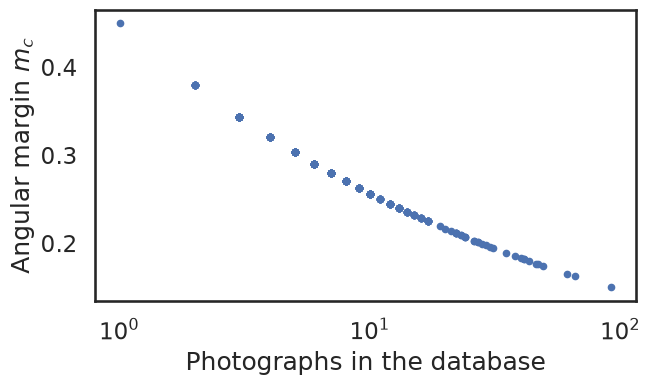

In [21]:
def margins_from_counts(counts, span=(0.15, 0.45), lam=0.25):
    '''A wider angular margin for individuals with fewer photographs.'''
    scaled = np.asarray(counts, dtype='float64') ** -lam
    a = (span[1] - span[0]) / (scaled.max() - scaled.min())
    b = span[1] - a * scaled.max()
    return (a * scaled + b).astype('float32')


database = turtles[(turtles.role == 'train') & (turtles.arm_time == 'database')]
counts = database.identity.value_counts().sort_values()

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(counts.to_numpy(), margins_from_counts(counts.to_numpy()), '.')
ax.set(xlabel='Photographs in the database', ylabel='Angular margin $m_c$', xscale='log')
fig.tight_layout()

## Choosing the margin, instead of assuming it

Here is the trap this session has been warning about, in the place where it actually caught us.

The first version of this notebook compared a plain head at a fixed $m = 0.3$ against a dynamic-margin
head over a fixed range $[0.15, 0.45]$, and concluded that the dynamic margin was harmful. That
comparison is worthless. Neither value was chosen; the two arms differed in a hyperparameter *as well
as* in the thing under test, and a hyperparameter held fixed across a comparison measures itself.

So `scripts/reid_sweep.py` gives every configuration its own margin and its own $k$, selected on the
tune individuals — 468 fits, two seeds each. And the first pass of *that* had to be thrown away too: it
selected $m = 0.5$ and $k = 4$, which were its own largest values. A search that stops at the edge of
its range has found a wall, not an optimum, so the grids were extended to $m \le 0.8$ and $k \le 8$ and
it was run again. The values below have neighbours on both sides.

margin  subcenters  tune mAP@R
arm    head                                     
random dynamic       0.3           4      0.2183
       plain         0.2           1      0.2177
       subcenter     0.3           4      0.2147
time   dynamic       0.4           4      0.1334
       plain         0.5           1      0.1308
       subcenter     0.5           4      0.1350

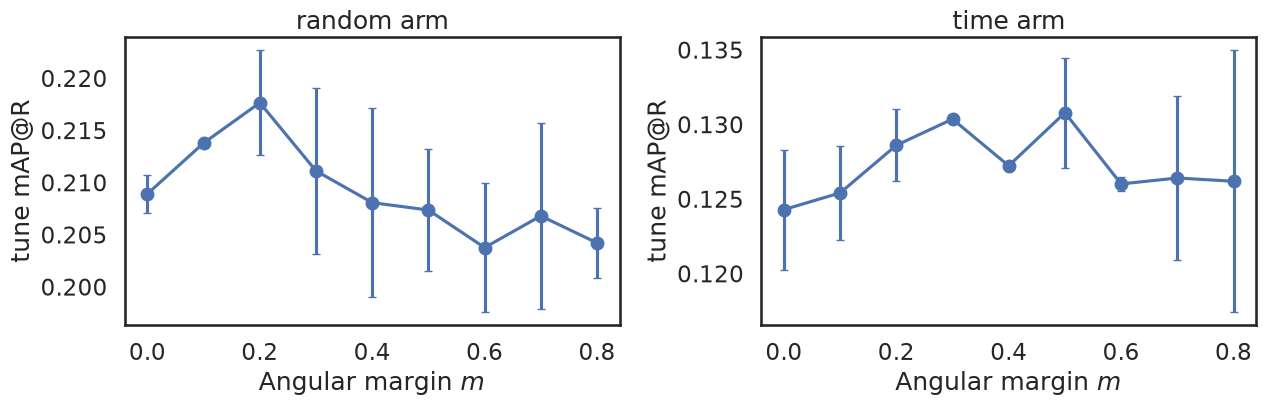

In [22]:
sweep = pd.read_csv(DATA / 'turtle_arcface_sweep.csv')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=False)
for ax, arm in zip(axes, ('random', 'time')):
    plain = sweep[(sweep['head'] == 'plain') & (sweep.arm == arm)]
    profile = plain.groupby('margin')['mAP@R'].agg(['mean', 'std'])
    ax.errorbar(profile.index, profile['mean'], yerr=profile['std'], marker='o', capsize=3)
    ax.set(title=f'{arm} arm', xlabel='Angular margin $m$', ylabel='tune mAP@R')
fig.tight_layout()

# k = 1 is the plain head wearing another name, so the sub-centered heads are
# restricted to k >= 2: the comparison below is the best sub-centered configuration
# against the best plain one, not against itself.
eligible = sweep[(sweep['head'] == 'plain') | (sweep.subcenters >= 2)]
selected = (eligible.groupby(['arm', 'head', 'margin', 'subcenters'])['mAP@R'].mean()
            .rename('tune mAP@R').reset_index())
selected = selected.loc[selected.groupby(['arm', 'head'])['tune mAP@R'].idxmax()]
selected.set_index(['arm', 'head']).round(4)

Left to itself the sweep picks $k = 1$ for the sub-centered head in the random arm — that is, it
declines to use sub-centers at all, which is already an answer. Since $k = 1$ is the plain head under
another name, the table restricts the sub-centered heads to $k \ge 2$ so that the comparison below is
between genuinely different models.

The margin profile is a gentle hill in the random arm, peaking around $m = 0.2$, and close to flat in
the time-aware arm, where the error bars cover almost the whole range. The margin is doing less work
here than the literature would suggest — which is itself worth knowing before spending a week tuning it.

## The result, with each head given its best shot

In [23]:
extensions = pd.concat({
    head: summarize(lambda arm, s, h=head: arcface_embeddings(arm, h, s))
    for head in ('plain', 'subcenter', 'dynamic')
}, axis=1).loc[['recall@1', 'mAP@R', 'recall@1 sd', 'mAP@R sd']]
extensions.round(4)

plain         subcenter         dynamic        
             random    time    random    time  random    time
recall@1     0.5981  0.2671    0.5763  0.2580  0.5648  0.2450
mAP@R        0.2137  0.1016    0.2002  0.0954  0.1775  0.0822
recall@1 sd  0.0051  0.0028    0.0057  0.0113  0.0044  0.0045
mAP@R sd     0.0044  0.0012    0.0113  0.0074  0.0160  0.0028

**Neither extension helps, and the dynamic margin hurts.** The plain head wins on both metrics in both
arms. Sub-centers cost about a point of top-1, which is one to two seed standard deviations — call it a
wash. The dynamic margin costs three to four points of top-1 and a fifth of the mAP@R, which is well
outside the spread.

The honest summary is narrow: *on this dataset, at this scale, with a frozen backbone, the extensions
do not pay for themselves.*

Why might that be? A plausible story is scale. MiewID uses sub-centers and a dynamic margin across 64
species and tens of thousands of individuals, where there are enough photographs for a class to split
into genuinely distinct modes and enough classes for the tail to dominate the loss. We have 300
individuals and a median of eleven database photographs each: give such a class four proxies and each
one is fitted from two or three images, which is a way of making an already undertrained proxy worse.
**That story is untested.** It predicts that the gap narrows as the number of training individuals
grows, and nothing in this notebook checks that — Exercise 4 is where you would start.

What generalizes is not "sub-centers are bad". It is that an extension which is standard practice in a
literature built on large datasets can be inert or harmful at the scale you are actually working at,
and the only way to find out is to give it its own hyperparameters and measure.

# The trap that eats fine-tuning runs

Everything above trains a head on frozen features. The obvious next step — the one every practitioner
takes — is to unfreeze the last block of the backbone and fine-tune. This is where re-identification
projects lose weeks, and the cause is a Keras behaviour that is documented, sensible, and almost never
what people expect on first contact.

**A `BatchNormalization` layer with `trainable = False` does not merely stop learning. It switches to
inference mode**: it uses the moving statistics it already has instead of the batch's, and stops
updating them. In most of Keras, `trainable = False` means "do not update these weights"; here it also
changes the forward pass. Let us check rather than assert.

In [24]:
probe = keras.layers.BatchNormalization()
probe.build((None, 4))
probe.trainable = False

to_numpy = keras.ops.convert_to_numpy

batch = np.random.normal(loc=5.0, scale=3.0, size=(64, 4)).astype('float32')
before = to_numpy(probe.moving_mean)
training_mode = to_numpy(probe(batch, training=True))
after = to_numpy(probe.moving_mean)

print('moving statistics updated under training=True:', not np.allclose(before, after))
print('training-mode output equals inference-mode output:',
      np.allclose(training_mode, to_numpy(probe(batch, training=False))))

moving statistics updated under training=True: False
training-mode output equals inference-mode output: True


Both answers are the ones that surprise people: the statistics are **not** updated, and the layer
behaves in training exactly as it does at inference.

For re-identification this is the behaviour you want, and it is standard practice in the field. A
fine-tuning batch here holds 32 photographs drawn from a few hundred individuals with a long tail, so
its mean and variance are a poor estimate of the population's, and they lurch from batch to batch.
Letting the moving statistics chase them degrades the embedding of every image in the database — which
is the usual reason a fine-tuned re-identification model scores *worse* than the frozen backbone it
started from, while its training loss looks excellent.

## The ordering trap

The second half is worse, because it silently undoes the first. Setting `trainable = True` on a model
re-enables **every layer inside it**, including the `BatchNormalization` layers you just switched off.
So the order of these two operations decides whether you get frozen BN or not, and both orders look
equally reasonable in a diff.

In [25]:
block = keras.Sequential([keras.layers.Dense(4), keras.layers.BatchNormalization()])

for layer in block.layers:
    layer.trainable = False
print('BatchNorm frozen:', not block.layers[1].trainable)

block.trainable = True          # the innocent-looking line
print('BatchNorm still frozen:', not block.layers[1].trainable)

BatchNorm frozen: True
BatchNorm still frozen: False


Which gives the recipe: unfreeze the backbone **first**, then walk its layers and switch the
normalization back off. `scripts/reid_arcface.py` has this as `build_finetune_trunk`, and the order of
the two assignments is the whole content of the function.

In [26]:
def build_finetune_trunk(seed, unfreeze_from='block6a'):
    '''EfficientNetV2S with its last block unfrozen and every BatchNorm kept frozen.'''
    backbone = keras.applications.EfficientNetV2S(
        weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))

    backbone.trainable = True                    # this re-enables everything, so it goes first
    unfrozen = False
    for layer in backbone.layers:
        if layer.name.startswith(unfreeze_from):
            unfrozen = True
        layer.trainable = unfrozen
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = False              # ... and this has to come after

    images = keras.Input(shape=(224, 224, 3), name='image')
    embeddings = keras.layers.Dense(EMBEDDING_DIM, use_bias=False, name='embedding',
                                    kernel_initializer=keras.initializers.GlorotUniform(seed=seed))(
        backbone(images))
    return keras.Model(images, embeddings, name='finetune_trunk')


trunk = build_finetune_trunk(SEED)
backbone = trunk.layers[1]
normalization = [l for l in backbone.layers if isinstance(l, keras.layers.BatchNormalization)]
trainable = [l for l in backbone.layers if l.trainable]

print(f'{len(trainable):3d} of {len(backbone.layers)} backbone layers are trainable')
print(f'{sum(l.trainable for l in normalization):3d} of {len(normalization)} BatchNorm layers are trainable')

181 of 514 backbone layers are trainable
  0 of 110 BatchNorm layers are trainable


Zero normalization layers trainable, with a block's worth of convolutions unfrozen: that is the
configuration re-identification practice uses.

We do not run this fine-tune in the notebook — it needs a GPU and it is not what this session is
teaching. The point is that the two lines whose order matters are the difference between a fine-tune
that helps and one that quietly destroys your database embeddings, and no error message will ever tell
you which one you wrote.

# Fine-tuning the backbone: where the performance actually comes from

Everything up to here has been a **probe** — a head fitted on features an ImageNet
classifier produced, with the backbone untouched. That is the right way to learn the
mechanics, and it is not how a working re-identification system is built. ImageNet
features were trained to separate *species*; nothing ever asked them to represent the
arrangement of scales behind one turtle's eye. Until gradients reach the backbone, the
information the task depends on may simply not be in the representation.

So now we let them. This is the same head and the same protocol; the only change is
that the last block of EfficientNetV2S trains too, with its BatchNorm frozen as the
section above insists.

## The recipe is borrowed, not tuned

Nothing below was chosen by us. It is the recipe the lab already uses to fine-tune
MiewID on this species, transplanted onto our backbone, and it agrees with
[Musgrave et al.](https://arxiv.org/abs/2003.08505) §3.1 where the two overlap:

| | value | why |
|---|---|---|
| backbone learning rate | `5e-6` | a pretrained backbone is nudged, not retrained |
| projection + ArcFace rate | `1e-4` (20x) | Musgrave §3.1: a loss with its own learnable weights gets its own rate |
| optimizer | AdamW, cosine annealing to `1e-6` | |
| batch | 32, shuffled | the sampler section above; the lab's script uses `MPerClassSampler(m=1)`, which is shuffling |
| ArcFace | `s = 64`, `m = 0.5`, one centre | |
| embedding | 512-d, `Linear` then `BatchNorm` | |
| unfrozen | `block6a` onwards, **every BatchNorm frozen** | |
| augmentation | horizontal flip, brightness, contrast | sea turtles are bilaterally symmetric, so a mirrored head crop is still a plausible photograph |

Keras has no per-layer learning rate, so the 20x that the projection and head get over
the backbone comes from the same `w = raw * mult` reparameterization the head already
uses. That is the trick from the companion session earning its keep twice.

In [27]:
# scripts/reid_arcface.py --finetune --max-epochs 250
# Six runs, two arms x three seeds, about 55 minutes each on an RTX A4000.

def finetune_embeddings(arm, seed=42):
    return np.load(DATA / f'turtle_finetune_{arm}_e250_s{seed}_embeddings.npy')


finetuned = pd.concat({
    'probe (frozen backbone)': summarize(lambda arm, s: arcface_embeddings(arm, 'plain', s)),
    'fine-tuned backbone': summarize(finetune_embeddings),
}, axis=1).loc[['recall@1', 'recall@5', 'mAP@R', 'recall@1 sd', 'mAP@R sd']]
finetuned.round(4)

probe (frozen backbone)         fine-tuned backbone        
                             random    time              random    time
recall@1                     0.5981  0.2671              0.7653  0.4580
recall@5                     0.7344  0.4188              0.8344  0.5570
mAP@R                        0.2137  0.1016              0.6089  0.3287
recall@1 sd                  0.0051  0.0028              0.0011  0.0028
mAP@R sd                     0.0044  0.0012              0.0125  0.0102

On the honest, time-aware split, top-1 goes from 0.27 to **0.46** and mAP@R from 0.10 to
**0.33** — the latter more than tripled. Nothing about the head changed. The gain is
entirely that the backbone is now allowed to represent what this task is about.

This is the answer to "why does re-identification work at all, when every turtle looks
like every other turtle": it works because the representation is *learned for the
task*, and a general-purpose one is not a substitute. Every other ingredient in this
session — the margin, the normalization, the protocol — is scaffolding around that.

## The budget nearly cost us the result

The first attempt at this used the lab's 50 epochs, and reported the following:

| | recall@1 | mAP@R | rejection AUC |
|---|---|---|---|
| probe | 0.267 | 0.102 | 0.641 |
| fine-tuned, 50 epochs | 0.271 | 0.092 | 0.578 |

Which reads as: *fine-tuning does not help, and makes rejection worse.* It is a clean,
plausible, completely wrong conclusion, and it was produced by the same recipe that
gives the table above. **Every one of those runs peaked at epoch 50 of 50.**

There is a wrinkle worth being precise about, because it is not quite the rule the
companion session gives. Under a cosine schedule the learning rate is annealed to
almost nothing at the end of the budget, so the best epoch lands near the end *by
construction* — the model is frozen where it happens to be. "Peak equals cap" therefore
does not mean the same thing here as it does under a constant learning rate, where the
metric would eventually turn back down.

The test that does mean something is: **does a longer budget still improve the result?**

In [28]:
budgets = pd.DataFrame({
    f'{epochs} epochs': {
        arm: np.mean([np.max([s['mAP@R'] for s in
                              pickle.load(open(DATA / f'turtle_finetune_{arm}_e{epochs}_s{seed}_history.p',
                                               'rb'))['tune']])
                      for seed in SEEDS])
        for arm in ('random', 'time')
    }
    for epochs in (150, 250)
})
budgets['seed sd (250)'] = [
    np.std([np.max([s['mAP@R'] for s in
                    pickle.load(open(DATA / f'turtle_finetune_{arm}_e250_s{seed}_history.p',
                                     'rb'))['tune']])
            for seed in SEEDS])
    for arm in ('random', 'time')
]
budgets.round(4)      # tune mAP@R, the individuals we are allowed to choose on

,150 epochs,250 epochs,seed sd (250)
random,0.3200,0.3367,0.0026
time,0.1879,0.1948,0.0055


In [29]:
peaks = pd.DataFrame({
    f'{epochs} epochs': {
        f'{arm} s{seed}': pickle.load(
            open(DATA / f'turtle_finetune_{arm}_e{epochs}_s{seed}_history.p', 'rb'))['peak_epoch']
        for arm in ('random', 'time') for seed in SEEDS
    }
    for epochs in (150, 250)
})
peaks

,150 epochs,250 epochs
random s42,148,247
random s43,149,187
random s44,149,225
time s42,146,214
time s43,145,153
time s44,147,222


At 150 epochs every run still peaked within a few epochs of its cap. At 250 the peaks
are genuinely interior — 153 to 247 — which is the criterion we act on.

Convergence is less tidy than that, and worth reporting rather than smoothing over. On
the time arm the gain from 150 to 250 epochs is about one seed standard deviation, so
that arm has converged. On the random arm it is roughly six, so the random arm is
*still improving* at 250 and its fine-tuned numbers are, if anything, an underestimate.
We stop here because the peaks are interior and because no conclusion in this notebook
turns on the difference — but "we stopped when it stopped mattering for our claim" is
the honest description, not "it converged".

Two practical lessons, and the second is the one that generalizes. First, 50 epochs was
*five times* too short, and the failure was silent — the loss curve looked fine.
Second, a rule of thumb ("the peak must have neighbours on both sides") is attached to
an assumption ("the learning rate is constant"), and when you change the assumption you
have to re-derive the test rather than recite it.

# Three questions, three metric families

"How good is this embedding" is not a question. These are questions:

1. **Ranking** — *will a human reviewing the top few candidates find the match?* This is the operational
   metric for a photo-identification workflow, which has a person in the loop. Recall@K and mAP@R,
   which is what we have been reporting.
2. **Rejection** — *is this individual in the database at all?* This is the decision that **defines**
   open-set re-identification, and no ranking metric can see it: mAP@R never asks about a query with no
   correct answer, because there is nothing to rank.
3. **Clustering** — *can the embedding partition individuals it has never seen, without supervision?*
   This is what you need when nobody has labelled anything yet, which is how most wildlife archives
   start.

They are not interchangeable, they do not move together, and reporting one while implying the others is
the most common way a re-identification result misleads. We report all three.

## Rejection: the question ranking cannot see

Every query gets a score — the similarity to its best match in the database — and a threshold turns
that into a decision: *in the database*, or *new individual*. The 50 `unknown` individuals were never
trained on and are in no database, so every one of their photographs should be rejected.

The threshold is a hyperparameter, so it is chosen on the tune individuals. To do that we need tune
individuals on both sides of the question, so half of them are removed from the tune database and play
the part of unknowns. The reported threshold is then applied, unchanged, to individuals it was not
chosen on.

In [30]:
def top_similarity(Z, query_rows, database_rows):
    return (normalize(Z[query_rows]) @ normalize(Z[database_rows]).T).max(axis=1)


def rejection_scores(Z, arm, known_role='train', unknown_role='unknown'):
    '''Similarity to the best database match, for queries that are in it and queries that are not.'''
    known = turtles[turtles.role == known_role]
    database = known.index[known[f'arm_{arm}'] == 'database'].to_numpy()
    query = known.index[known[f'arm_{arm}'] == 'query'].to_numpy()
    unknown = turtles.index[turtles.role == unknown_role].to_numpy()
    return top_similarity(Z, query, database), top_similarity(Z, unknown, database)


def tune_rejection_scores(Z, arm, n_known=25):
    '''The same thing on the tune individuals, half of them held out of the database.'''
    tune = turtles[turtles.role == 'tune']
    known_ids = set(np.sort(tune.identity.unique())[:n_known])
    known = tune[tune.identity.isin(known_ids)]
    database = known.index[known[f'arm_{arm}'] == 'database'].to_numpy()
    query = known.index[known[f'arm_{arm}'] == 'query'].to_numpy()
    unknown = tune.index[~tune.identity.isin(known_ids)].to_numpy()
    return top_similarity(Z, query, database), top_similarity(Z, unknown, database)


def choose_threshold(in_database, novel):
    '''The threshold with the best balanced accuracy.'''
    candidates = np.unique(np.concatenate([in_database, novel]))
    accuracy = [(in_database >= t).mean() / 2 + (novel < t).mean() / 2 for t in candidates]
    best = int(np.argmax(accuracy))
    return candidates[best], accuracy[best]

In [31]:
from sklearn.metrics import roc_auc_score


def rejection_report(Z, arm):
    threshold, tune_accuracy = choose_threshold(*tune_rejection_scores(Z, arm))
    in_database, novel = rejection_scores(Z, arm)
    labels = np.r_[np.ones(len(in_database)), np.zeros(len(novel))]
    return {
        'AUC': roc_auc_score(labels, np.r_[in_database, novel]),
        'accuracy': (in_database >= threshold).mean() / 2 + (novel < threshold).mean() / 2,
        'threshold': threshold,
        'accuracy on tune': tune_accuracy,
    }


rejection = pd.DataFrame({
    ('frozen', arm): rejection_report(frozen, arm) for arm in ('random', 'time')
} | {
    ('ArcFace', arm): rejection_report(arcface_embeddings(arm, 'plain', 42), arm)
    for arm in ('random', 'time')
})
rejection.round(3)

frozen        ArcFace       
                 random   time  random   time
AUC               0.640  0.584   0.747  0.643
accuracy          0.595  0.558   0.652  0.596
threshold         0.948  0.948   0.456  0.597
accuracy on tune  0.655  0.588   0.770  0.611

Three things worth noticing.

**Rejection is much harder than the ranking numbers suggest.** An AUC in the sixties and low seventies
means the similarity distributions of "in the database" and "new animal" overlap heavily. A system that
ranks tolerably can still be unable to tell you whether the right answer is in the list at all — and in
a survey, "is this a new individual" is often the question the ecology actually depends on.

**The threshold does not transfer perfectly.** Balanced accuracy on the tune individuals is several
points above the accuracy the same threshold achieves on the reported ones. That gap is the cost of
choosing a hyperparameter honestly, and it is the number you would have hidden from yourself by
choosing the threshold on the reported individuals instead.

**The arms disagree here too**, in the same direction and for the same reason.

## Clustering, and the k problem

Now suppose nothing is labelled. Can the embedding recover the individuals on its own? We cluster the
photographs of the 50 `unknown` individuals and score the partition with the adjusted Rand index
against the true identities. There is deliberately **no trainable clustering head**: adding one would
confound the quality of the embedding with the quality of a clustering objective, and the question here
is about the embedding.

The interesting part is k. Two ways to run this, and they measure different things:

- **oracle k** — tell the algorithm there are exactly 50 individuals. This hands it the answer to the
  hardest part of the open-set problem, so it is not an open-set measurement.
- **estimated k** — give it a distance threshold instead and let it decide. Now the score depends
  sharply on that threshold, so part of what you measure is how well you tuned it.

Both are reported, and both the linkage and the threshold are chosen on the tune individuals — for each
mode separately, since a linkage that suits one need not suit the other.

In [32]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score

LINKAGES = ('average', 'complete', 'ward')
THRESHOLDS = np.arange(0.1, 1.5, 0.05)
# ward is defined for Euclidean distance only; on unit-normalized rows that is a
# monotone function of the cosine, so the neighbour order is the same.
linkage_kwargs = lambda linkage: {} if linkage == 'ward' else dict(metric='cosine')


def cluster(E, linkage, n_clusters=None, distance_threshold=None):
    return AgglomerativeClustering(n_clusters=n_clusters, distance_threshold=distance_threshold,
                                   linkage=linkage, **linkage_kwargs(linkage)).fit_predict(E)


def embeddings_of(Z, role):
    rows = turtles.index[turtles.role == role].to_numpy()
    return normalize(Z[rows]), pd.factorize(turtles.loc[rows, 'identity'])[0]


def clustering_report(Z):
    tune, tune_labels = embeddings_of(Z, 'tune')
    unknown, unknown_labels = embeddings_of(Z, 'unknown')
    k = len(np.unique(unknown_labels))

    # Chosen on tune, for each mode separately.
    oracle_linkage = max(LINKAGES, key=lambda l: adjusted_rand_score(
        tune_labels, cluster(tune, l, n_clusters=len(np.unique(tune_labels)))))
    estimated = max(((l, t) for l in LINKAGES for t in THRESHOLDS),
                    key=lambda lt: adjusted_rand_score(
                        tune_labels, cluster(tune, lt[0], distance_threshold=lt[1])))

    oracle_partition = cluster(unknown, oracle_linkage, n_clusters=k)
    estimated_partition = cluster(unknown, estimated[0], distance_threshold=estimated[1])
    return {
        'ARI (oracle k)': adjusted_rand_score(unknown_labels, oracle_partition),
        'ARI (estimated k)': adjusted_rand_score(unknown_labels, estimated_partition),
        'k estimated': len(np.unique(estimated_partition)),
        'k true': k,
        'linkage': f'{oracle_linkage} / {estimated[0]} @ {estimated[1]:.2f}',
    }


clustering = pd.DataFrame({
    ('frozen', arm): clustering_report(frozen) for arm in ('random', 'time')
} | {
    ('ArcFace', arm): clustering_report(arcface_embeddings(arm, 'plain', 42))
    for arm in ('random', 'time')
})
clustering

frozen                      \
                               random                time   
ARI (oracle k)               0.135773            0.135773   
ARI (estimated k)            0.157025            0.157025   
k estimated                       135                 135   
k true                             50                  50   
linkage            ward / ward @ 0.70  ward / ward @ 0.70   

                                 ArcFace                         
                                  random                   time  
ARI (oracle k)                  0.295077               0.331256  
ARI (estimated k)               0.395902                0.34562  
k estimated                          157                    232  
k true                                50                     50  
linkage            ward / average @ 0.75  ward / average @ 0.55

This table contains the most surprising result in the session, and it is not the one the question was
set up to produce.

**Estimated k scores *better* than oracle k** — despite the estimate being wrong by a factor of three
to five. Telling the algorithm the true number of individuals makes the partition worse.

The reason is worth sitting with, because it is a fact about the metric rather than about turtles. Given
the true k, agglomerative clustering is forced to keep merging until it has exactly 50 clusters, and the
last merges join groups that do not belong together — each one contaminating two individuals at once.
Given a distance threshold, it stops while its clusters are still *pure*, and leaves one turtle split
across four small clusters. The adjusted Rand index punishes the first mistake far more than the second.
So the embedding is better at saying "these two photographs are the same turtle" than at saying "there
are fifty turtles here".

Two lessons follow. First, **an ARI is not a property of an embedding**; it is a property of an
embedding, a linkage, a stopping rule and a metric's opinion about which errors are bad. The first
version of this notebook reported an oracle-k ARI of 0.014 for one model, purely because the linkage had
been chosen for the other mode — a ten-fold difference from a decision nobody would think to report.
Second, if what you deploy is "merge photographs that are obviously the same animal and leave the rest
for a human", the estimated-k column is the one that describes your system, and the oracle-k column
describes an experiment nobody can run in the field, because nobody knows how many turtles there are.
That is the whole reason for counting them.

Note also that the frozen columns are identical across arms, as they must be — those embeddings never
saw a split. It is a useful check that the pipeline is doing what it claims.

# Few-shot, which is not a separate topic here

A long-tailed identity distribution **is** the few-shot regime. Half our individuals have ten
photographs or fewer; a working photo-identification project meets most of its animals once. So
few-shot is not an extra experiment bolted on at the end — it is the normal operating condition, and it
needs no additional training at all.

The method is nearest-class-mean, which is ProtoNet at inference: average the support embeddings of
each individual into a prototype, and assign each query to the nearest one. On a metric that is already
trained, this is three lines.

In [33]:
def prototypes(E, labels, support):
    '''Average the support embeddings of each individual, back onto the unit sphere.'''
    classes = np.unique(labels[support])
    return classes, normalize(np.stack([E[support & (labels == c)].mean(axis=0) for c in classes]))


def nearest_class_mean(E, labels, support, query):
    classes, means = prototypes(E, labels, support)
    predicted = classes[(E[query] @ means.T).argmax(axis=1)]
    return (predicted == labels[query]).mean()

Now, how to choose the support images — the same question the whole session is about, arriving once
more in a place where it is easy to miss.

The obvious choice is to draw the support set **at random** from each individual's photographs. But
these individuals were photographed in encounters, so a random support set of five is often five
pictures from one afternoon, and the queries include the rest of that afternoon. We would be measuring
encounter matching all over again, inside an experiment that has nothing to do with the earlier split.

So we do it both ways: support drawn at random from all of an individual's photographs, and support
taken from its **earliest** photographs with every query required to come from a strictly later day.

In [34]:
def few_shot(Z, shots, support_from, role='unknown', repeats=20, seed=SEED):
    '''Nearest-class-mean accuracy on individuals the model has never seen.'''
    rows = turtles.index[turtles.role == role].to_numpy()
    E, sub = normalize(Z[rows]), turtles.loc[rows]
    labels, dates = pd.factorize(sub.identity)[0], sub.date.to_numpy()
    generator = np.random.default_rng(seed)

    accuracies = []
    for _ in range(repeats if support_from == 'anywhere' else 1):
        support = np.zeros(len(labels), dtype=bool)
        askable = np.zeros(len(labels), dtype=bool)
        for c in np.unique(labels):
            idx = np.flatnonzero(labels == c)
            if len(idx) <= shots:
                continue
            if support_from == 'anywhere':
                support[generator.choice(idx, shots, replace=False)] = True
                askable[idx] = True
            else:
                earliest = idx[np.argsort(dates[idx], kind='stable')][:shots]
                later = idx[dates[idx] > dates[earliest].max()]
                if len(later) == 0:
                    continue              # nothing on a later day to ask about
                support[earliest] = True
                askable[later] = True
        classes = np.unique(labels[support])
        query = askable & ~support & np.isin(labels, classes)
        accuracies.append(nearest_class_mean(E, labels, support, query))
    return np.mean(accuracies)


few_shot_table = pd.DataFrame({
    (model, support_from): {f'{k}-shot': few_shot(Z, k, support_from) for k in (1, 2, 5)}
    for model, Z in (('frozen', frozen), ('ArcFace', arcface_embeddings('time', 'plain', 42)))
    for support_from in ('anywhere', 'earliest')
})
few_shot_table.round(3)

frozen           ArcFace         
       anywhere earliest anywhere earliest
1-shot    0.197    0.185    0.302    0.200
2-shot    0.254    0.145    0.399    0.232
5-shot    0.330    0.232    0.563    0.288

Read the two ArcFace columns down the rows.

With support drawn from anywhere, accuracy climbs steeply with the number of shots — from 0.30 to 0.56,
nearly doubling. With support taken from the earliest encounter and queries forced onto later days, the
same five-fold increase in photographs buys about nine points, from 0.20 to 0.29: a real gain, and a
third of the size.

**The number of shots is not the amount of information.** Five photographs taken over one afternoon are
five views of one pose, one lighting, one angle: a single observation, sampled five times. Much of the
steep curve in the `anywhere` column is the model getting more chances to match a query against a
near-duplicate of itself — and it would be reported, in perfectly good faith, as evidence that the
method scales well with shots.

One honest caveat about this particular comparison: the two protocols differ in their *query* pools as
well as their support sets, since `earliest` can only ask about photographs from later days. So the two
columns are not matched the way the two arms of the split were, and the absolute gap between them is
not a clean effect estimate. The shape of each column down the rows is the finding, and it does not
depend on comparing the columns to each other.

If you are designing a survey protocol, this is the practical form of the lesson: photographing one
animal twenty times in a single encounter is worth much less than photographing it twice, in two
seasons.

# What a purpose-built model does

Everything so far has been built from an ImageNet backbone and 300 turtles. The field has models
trained for this job on far more data, and the honest thing to do is to put one next to ours.

**MiewID-msv3** is a wildlife re-identification backbone from Wild Me: EfficientNetV2-RW-M, about 51M
parameters, trained contrastively with a sub-center ArcFace head (k = 3, scale 51.5, a dynamic margin
starting at 0.5) on 64 wildlife species from Wildbook, emitting a 2,152-d embedding. It is PyTorch, and
this course does not install PyTorch, so `scripts/reid_precompute_torch.py` runs it once outside the
course environment and what we load here is an array.

The comparison is *roughly architecture-controlled*, which is a stronger claim than "we compare to a
pretrained solution": our backbone is from the same family and, since the previous section, trained
with the same recipe, so what differs is mostly **training data**. Two caveats keep that from being
exact — "RW" is the `timm` variant, not `keras.applications.EfficientNetV2M`, and we use **-S** rather
than **-M** for runtime, at 224 px rather than 440. So our numbers are not MiewID-scale by
construction.

In [35]:
miewid = np.load(DATA / 'turtle_miewid_embeddings.npy')
print('MiewID embeddings:', miewid.shape)

comparison = pd.DataFrame({
    (name, arm): {**evaluate(Z, arm),
                  'rejection AUC': rejection_report(Z, arm)['AUC']}
    for name, Z in (('frozen EffNetV2S', frozen),
                    ('probe', arcface_embeddings('time')),
                    ('ours, fine-tuned', finetune_embeddings('time')),
                    ('MiewID-msv3', miewid))
    for arm in ('random', 'time')
}).loc[['recall@1', 'recall@5', 'mAP@R', 'rejection AUC']]
comparison.round(3)

MiewID embeddings: (7582, 2152)


frozen EffNetV2S         probe        ours, fine-tuned         \
                        random   time random   time           random   time   
recall@1                 0.384  0.134  0.646  0.263            0.845  0.461   
recall@5                 0.532  0.266  0.791  0.419            0.905  0.555   
mAP@R                    0.052  0.022  0.200  0.103            0.479  0.337   
rejection AUC            0.640  0.584  0.744  0.643            0.893  0.699   

              MiewID-msv3         
                   random   time  
recall@1            0.948  0.928  
recall@5            0.962  0.945  
mAP@R               0.794  0.773  
rejection AUC       0.927  0.900

MiewID is still well ahead — top-1 in the nineties against our forties, mAP@R 0.77 against 0.33 — but
the gap is now a *quantitative* one between two models of the same family trained the same way, rather
than the categorical gap it was against the probe. What separates them is the training data: 64 species
and tens of thousands of individuals from Wildbook, against our 300 turtles.

That is the honest summary of this whole session's modelling. The recipe is not the hard part; the
recipe is in the literature and we copied it. The data is the hard part.

In [36]:
pd.DataFrame({'MiewID-msv3': clustering_report(miewid),
              'ours, fine-tuned (time arm)': clustering_report(finetune_embeddings('time')),
              'probe (time arm)': clustering_report(arcface_embeddings('time')),
              'frozen EffNetV2S': clustering_report(frozen)})

,MiewID-msv3,"ours, fine-tuned (time arm)",probe (time arm),frozen EffNetV2S
ARI (oracle k),0.918403,0.483321,0.331256,0.135773
ARI (estimated k),0.916227,0.517034,0.34562,0.157025
k estimated,69,105,232,135
k true,50,50,50,50
linkage,ward / complete @ 0.70,average / average @ 0.80,ward / average @ 0.55,ward / ward @ 0.70


An ARI of 0.92 on 50 individuals it was never given labels for, with the estimated number of clusters
within a factor of 1.4 of the truth, is a usable automatic system. Ours is not there, but note how far
fine-tuning moved it from the probe — and that no amount of tuning the *head* had done anything
comparable.

Worth one sentence against the reflex that transformers dominate everything: the MiewID authors report
EfficientNetV2 beating SwinV2-Base by about 4.5% in their setting. The convolutional backbone in this
notebook is not a legacy choice.

## A diagnostic hiding in the two arms

Now compare how much each model *cares* about the split.

In [37]:
sensitivity = pd.DataFrame({
    name: {arm: evaluate(Z, arm)['recall@1'] for arm in ('random', 'time')}
    for name, Z in (('frozen EffNetV2S', frozen),
                    ('probe', arcface_embeddings('time')),
                    ('ours, fine-tuned', finetune_embeddings('time')),
                    ('MiewID-msv3', miewid))
}).T
sensitivity['inflation'] = sensitivity['random'] / sensitivity['time']
sensitivity.round(3)

,random,time,inflation
frozen EffNetV2S,0.384,0.134,2.870
probe,0.646,0.263,2.452
"ours, fine-tuned",0.845,0.461,1.834
MiewID-msv3,0.948,0.928,1.022


Each row here holds **one** embedding fixed and changes only the protocol it is scored under, which is
why our row uses the time-arm model in both columns rather than a different model per arm as the
headline table did. The question is what the split does, not what training on it does.

The inflation falls monotonically as the embedding gets better: about 2.9 for the frozen backbone, 2.5
for the probe, 1.8 once the backbone is fine-tuned, and 1.02 for MiewID — which barely notices.

That is worth thinking about carefully, because it cuts against a lazy reading of this session. The
encounter shortcut is most valuable to a model that cannot do the real task. A model that genuinely
recognises the individual does not need to recognise the afternoon, so moving its queries to later days
costs it almost nothing. **The inflation from a bad split is largest exactly where the model is
weakest** — which is to say, exactly when you are most likely to be fooled into thinking your method
works.

There is a second explanation for a small gap, and we cannot rule it out. A model that has already
trained on these very photographs would also show almost no gap, because for it neither arm is open-set
at all. MiewID's card says 64 species from Wildbook and does not enumerate the archives; this is one of
the best-known sea turtle datasets, and we have no way to verify that it is absent. Both explanations —
"genuinely strong" and "has seen these turtles" — predict the same signature here, so the diagnostic is
suggestive and not conclusive.

What it does support is a habit: **report both arms for every model you compare against, including
other people's.** A model whose gap is large is leaning on the shortcut. A model whose gap is small is
either very good or has seen your data, and which of those it is a question worth asking out loud.

# Deep local descriptors: a different inductive bias, not a better model

Everything in this session has produced one vector per image. That is a choice, and it has a cost that
is easy to state: a global embedding is a summary, and a summary of a turtle's head is mostly *not* the
handful of scales that identify it.

The alternative is to keep the geometry. **ALIKED** detects keypoints and describes their local
neighbourhoods; **LightGlue** takes two such sets and decides which keypoint in one image corresponds to
which in the other, using an attention network that reasons about the whole configuration at once. What
comes out is not a similarity — it is a set of correspondences, which can be counted, plotted, and
checked against a geometric model.

The two families fail in opposite directions, and that is the useful way to hold them:

| | global embedding | local descriptors |
|---|---|---|
| what it preserves | overall appearance, texture, colour | spatial correspondence between specific points |
| wants | many images per individual, to learn from | one clear image per individual, no training |
| good at | holistic identity, soft cues, fur and flank patterns | rigid, distinctive, repeatable patterns |
| cost to compare | one dot product | a network forward pass **per pair** |
| scaling | index millions, search in milliseconds | $O(N^2)$, and the constant is not small |

So this is not "local descriptors beat metric learning". Metric learning wins where identity is holistic
and training data is plentiful; keypoint matching wins where the pattern is rigid and distinctive and
each individual has one or two photographs — and it works **zero-shot**, with no training at all, which
is exactly the regime a new species arrives in.

This section is based on Yesharim et al. (2026, *Ecological Informatics*), which applies ALIKED and
LightGlue to individual identification and is the source of the hybrid below.

LightGlue is PyTorch, so as with MiewID nothing here runs it live: `scripts/reid_precompute_torch.py`
computed the match counts once, outside the course environment.

## What a correspondence looks like

Three pairs from our own shortlists, drawn with the ALIKED keypoints that LightGlue matched. Each green
line joins a point in one photograph to the point it was matched to in the other.

![ALIKED + LightGlue correspondences](img/reid_lightglue_matches.png)

The top pair is what the method is for: two photographs of one turtle, years apart, and the scale
boundaries line up into a coherent, consistent geometry — a correspondence you could check by eye. The
middle pair is the same individual with far fewer correspondences, which is the regime where the count
alone starts to be a weak signal.

The bottom pair is the one to study. It is a **false** match — two different turtles — with a hundred
correspondences, more than the genuine match above it. Loggerhead head scales are similar in layout
across individuals, so a matcher that asks "do these regions look alike and sit in a plausible
arrangement" can answer yes with confidence. This is why a production pipeline adds geometric
verification, and why the count is a *re-ranking* score rather than a decision.

## The cost is the point

Before the result, the arithmetic that decides the architecture. Our time-aware arm has 3,744 queries
and a database of 3,838 images.

In [38]:
queries = (turtles.arm_time == 'query').sum()
gallery = (turtles.arm_time == 'database').sum()
pairs = queries * gallery
rate = 8        # LightGlue pairs per second, measured on a CPU core

print(f'{queries:,} queries x {gallery:,} database images = {pairs:,} pairs')
print(f'at {rate} pairs/s that is {pairs / rate / 3600:,.0f} hours of matching')
print(f'the same queries against a top-10 shortlist: {queries * 10:,} pairs, '
      f'{queries * 10 / rate / 60:.0f} minutes')

3,744 queries x 3,838 database images = 14,369,472 pairs
at 8 pairs/s that is 499 hours of matching
the same queries against a top-10 shortlist: 37,440 pairs, 78 minutes


Fourteen million pairs is not a database query, it is a weekend. And it does not improve with a bigger
machine in any way that matters, because it grows with the size of the archive — which for a
photo-identification project grows every field season.

This is why the deployed answer is neither method alone but a **hybrid**: use the embedding to retrieve
a shortlist, which is a matrix multiply, then spend the expensive local matching only on the handful of
candidates that survived. Retrieval provides recall, re-ranking provides precision.

## Exercise: implement the hybrid and measure what it buys

`turtle_lightglue_topk.npz` holds, for every query in the time-aware arm, its top-10 database
candidates by embedding cosine similarity and the number of LightGlue correspondences for each of those
pairs. That is precisely what the first stage of a hybrid would have computed.

Your job is the second stage, and it is about five lines of numpy.

In [39]:
hybrid = np.load(DATA / 'turtle_lightglue_topk.npz')
query_rows = hybrid['query_rows']            # row in `turtles` of each query
shortlist = hybrid['shortlist']              # (queries, 10) rows of the top-10 candidates
embedding_similarity = hybrid['embedding_similarity']    # (queries, 10) cosine similarity
local_score = hybrid['lightglue_score']      # (queries, 10) LightGlue correspondences

identity = turtles.identity.to_numpy()
correct = identity[shortlist] == identity[query_rows][:, None]   # (queries, 10)

# The usual three-way split of individuals, carried over: choose any weight on the
# tune queries, report on the train ones, and leave the unknowns out of a metric
# that assumes the answer exists.
role = turtles.role.to_numpy()[query_rows]
reported, tune_queries = role == 'train', role == 'tune'

print(f'{reported.sum():,} reported queries, shortlist of {shortlist.shape[1]}')
print('the answer is in the shortlist at all for '
      f'{correct[reported].any(axis=1).mean():.1%} of them')
print('LightGlue correspondences: {:.0f} for correct pairs, {:.0f} for wrong ones'.format(
    local_score[reported][correct[reported]].mean(),
    local_score[reported][~correct[reported]].mean()))

2,578 reported queries, shortlist of 10
the answer is in the shortlist at all for 47.6% of them
LightGlue correspondences: 114 for correct pairs, 39 for wrong ones


In [40]:
def top1(chosen, mask):
    '''Top-1 accuracy when `chosen[i]` is the shortlist position picked for query i.'''
    return correct[mask][np.arange(mask.sum()), chosen[mask]].mean()


# The embedding's own top-1: the shortlist is already sorted by similarity.
embedding_top1 = top1(np.zeros(len(shortlist), dtype=int), reported)

# TODO 1: re-rank each shortlist by the local match score and compute top-1.
# reranked_top1 = top1(..., reported)

# TODO 2: fuse the two scores instead of replacing one with the other -- for example a
#   weighted sum of row-standardized scores. Choose the weight on `tune_queries` and
#   only then report it on `reported`.
# fused_top1 = ...

print(f'embedding alone: top-1 = {embedding_top1:.3f}')

embedding alone: top-1 = 0.250


Three things to check once it runs, in the order that matters.

1. **The ceiling.** Re-ranking can never exceed the fraction of queries whose correct answer is in the
   shortlist at all — printed above. A re-ranker cannot retrieve what retrieval missed, and comparing a
   fusion gain to anything other than that ceiling overstates it.
2. **The gain.** How much of the gap between the embedding's top-1 and that ceiling does local matching
   close?
3. **Where it comes from.** Split the queries by how many photographs the individual has in the
   database, and compare the gain across groups. Be careful here, because the obvious version of this
   comparison is confounded: groups differ in their *headroom* as well as in their difficulty, since an
   individual with three database photographs is far less likely to have the right answer in the
   shortlist at all. Measure the gain both raw and as a fraction of the headroom available to that
   group, and see whether the two disagree. They do, and only one of them answers the question you
   meant to ask.

A fourth, for the ambitious: the local score here is a raw correspondence count, which favours images
with many keypoints — big, sharp, well-lit crops. Normalizing by the number of detected keypoints, or
adding a RANSAC geometric-verification step and counting only inliers, is what a production system
does. Does it help here?

The worked solution is in [`solutions/reid.ipynb`](../solutions/reid.ipynb).

# Discussion

**What makes re-identification work.** Strip the session to its mechanism and it is three things, in
order of how much they mattered here.

*A representation learned for the task.* Frozen ImageNet features get 0.13 top-1 on the honest split.
The same head on a fine-tuned backbone gets 0.46, and mAP@R more than triples. ImageNet was trained to
separate species; identifying an individual needs information it was never asked to keep. Everything
else in this notebook is scaffolding around that one fact.

*A loss that shapes a space rather than a decision boundary.* Normalizing the proxies and the embedding
turns the logit into an angle, and the angular margin forces classes apart by a gap rather than a
boundary — which is what makes the space useful for the individuals the head never had a proxy for.
That is most of them, forever, and it is why a classifier is the wrong object here.

*A protocol that measures the thing you care about.* Which turns out to be the largest single number in
the notebook, and the rest of this discussion.

**And what makes it work well in practice**: data, more than recipe. MiewID reaches 0.93 top-1 on the
split where we reach 0.46, using the same architecture family and a recipe we copied. The gap is 64
species and tens of thousands of individuals.

---

The session also spent a lot of its length on measurement, because the measurements kept overturning
the draft. The discarded drafts are worth listing, since each failed in a way that looked like a
result.

**The split is the biggest number in the notebook.** The same frozen embeddings score 0.38 or 0.13 top-1
depending only on whether queries may match photographs from their own day; our fitted model scores 0.60
or 0.27. No architectural choice available to us moved anything by half that much. And the inflation is
worst exactly where the model is weakest — MiewID, which can actually do the task, barely notices the
difference. A random split flatters bad models specifically.

**"How good is it" was three questions with three answers.** Our ArcFace embedding roughly doubles the
frozen baseline's ranking, improves rejection by less, and its clustering depends more on the linkage
you pick than on which of the two models produced the embedding. We reported a rejection threshold that
lost several points moving from the individuals it was chosen on to the ones we report — a gap that
exists only because we chose it honestly, and that would have been invisible otherwise.

**The fine-tuning budget was five times too short, and said the opposite.** At the lab's 50 epochs the
fine-tune scored *below* the probe and looked like evidence that fine-tuning hurts. Every run had
peaked at its own last epoch. At 250 the peaks are interior and fine-tuning is the largest effect in
the session. Nothing about the recipe changed.

**Two standard extensions did nothing, and one hurt** — sub-centers and a frequency-dependent margin,
each given its own margin and $k$ selected on held-out individuals. The useful form of that is not
"sub-centers are bad" but "an extension that is standard practice at one scale can be inert at another,
and you cannot tell without giving it its own hyperparameters". Note which things did and did not
matter: the head's refinements were worth nothing, and letting gradients into the backbone was worth
everything.

**The batch-composition question the companion session deferred got a negative answer.** A proxy loss
really is indifferent to whether its batches contain positive pairs, and an m-per-class sampler — the
standard remedy for a long tail — made things worse, because touching every proxy often matters more
than touching a few repeatedly.

**Two searches selected a value at the edge of their own range** before we caught them, one of them in
the sweep built specifically to avoid the confound. Extending the grids moved the winner. This mistake
does not announce itself: it produces a number, a table and a plausible sentence.

**ARI turned out not to be a property of an embedding.** Changing only the linkage moved it by a factor
of ten. Estimated $k$ beat oracle $k$ despite being wrong by three to five times, because the metric
punishes impure merges far more than over-segmentation. If you report a clustering number without
reporting how you clustered, you have reported almost nothing.

**Few-shot accuracy climbed steeply with shots, and most of the climb was an artifact.** Support images
drawn at random come from the same encounters as the queries; support images taken from the earliest
encounter do not, and then one shot and five shots are worth about the same. The number of photographs
is not the amount of information.

What survives all of that is a short list. Metric learning helps, substantially and reproducibly, in
both arms. A purpose-built model trained on far more data helps enormously more, and the gap is data,
not architecture. Local descriptors are not a competitor but a complement with an opposite inductive
bias, deployed as a re-ranker because the quadratic cost forbids anything else. And the discipline the
companion session introduced — choose on held-out classes, treat "how long to train" as a
hyperparameter, report the seed spread — is not scrupulousness for its own sake. Every result above
that turned out to be wrong was wrong because some version of it had been skipped.

One last thing, aimed squarely at the ecology. The point of this pipeline is not top-1 accuracy. It is
that somebody wants to know how many loggerheads use this bay, whether the same animals return, and
whether there are more of them than last year. A model with mediocre ranking and honest rejection may
serve that question better than a model with excellent ranking that confidently matches every new
turtle to one it has seen before. Choose the metric that matches the decision.

# Exercises

**Exercise 1 — the split, on your own data.** Take any re-identification dataset with timestamps
(`wildlife-datasets` has dozens) and report top-1 under a random split and a time-aware split of the
same photographs. Report the same-day leak fraction for both. If the gap is small, find out why: it
usually means the archive has one photograph per encounter, which is worth knowing.

**Exercise 2 — a rejection curve.** We reported rejection at a single threshold chosen on the tune
individuals. Plot the whole curve instead: the fraction of unknown individuals correctly rejected
against the fraction of known individuals wrongly rejected, as the threshold sweeps. Mark the operating
point we chose. Which end of the curve would a population survey want, and which end would an
automated tag-reader want?

**Exercise 3 — the scale $s$.** We fixed $s = 30$ throughout, and the companion session's own experience
is a warning: a sweep over $s \in \{16, 30, 64\}$ once reported "best $s = 16$" when 16 was the smallest
value it tried, and extending the grid downwards moved the optimum and reversed a conclusion. Sweep $s$
on the tune individuals, with a grid wide enough that the winner has neighbours on both sides, and see
whether $s = 30$ survives.

**Exercise 4 — how many photographs does a proxy need?** Group the reported individuals by how many
database photographs they have and compute top-1 within each group. Plot it against the group's size.
This is the long tail measured directly, and it tells you where any further effort should go.

**Exercise 5 — orientation.** The catalogue has an `orientation` column. Compute top-1 separately for
queries whose orientation matches their best database candidate and queries where it does not. How much
of what the embedding "knows" is really about pose? Then decide whether a production system should
index left-facing and right-facing photographs as separate galleries.

# References

**The dataset and its protocol**

- Adam, Čermák, Papafitsoros & Picek 2024, [SeaTurtleID2022: A Long-Span Dataset for Reliable Sea Turtle Re-Identification](https://openaccess.thecvf.com/content/WACV2024/html/Adam_SeaTurtleID2022_A_Long-Span_Dataset_for_Reliable_Sea_Turtle_Re-Identification_WACV_2024_paper.html), WACV — the archive, and the argument for time-aware splits that this session is built around.
- Čermák, Picek, Adam & Papafitsoros 2023, [WildlifeDatasets: An open-source toolkit for animal re-identification](https://arxiv.org/abs/2311.09118), WACV 2024 — the loader and the splitting protocols.
- Čermák et al. 2022, [Learning to Re-identify Animals](https://arxiv.org/abs/2211.10307) — the time-proportion split used here.

**The head**

- Deng, Guo, Xue & Zafeiriou 2019, [ArcFace: Additive Angular Margin Loss for Deep Face Recognition](https://arxiv.org/abs/1801.07698), CVPR.
- Deng, Guo, Liu, Gong & Zafeiriou 2020, [Sub-center ArcFace: Boosting Face Recognition by Large-scale Noisy Web Faces](https://arxiv.org/abs/2007.12137), ECCV.
- Ha, Liu & Liu 2020, [Google Landmark Recognition 2020 Competition: Third Place Solution](https://arxiv.org/abs/2010.05350) — the margin-by-class-frequency formulation.
- Musgrave, Belongie & Lim 2020, [A Metric Learning Reality Check](https://arxiv.org/abs/2003.08505), ECCV — separate learning rates for heads with learnable weights, and mAP@R.

**Wildlife re-identification systems**

- Otarashvili, Munkhbayar et al. 2024, [MiewID: Wildlife Re-Identification at Scale](https://github.com/WildMeOrg/wbia-plugin-miew-id) and the [`conservationxlabs/miewid-msv3`](https://huggingface.co/conservationxlabs/miewid-msv3) model card.
- Čermák, Papafitsoros, Adam & Picek 2024, [WildlifeDatasets / MegaDescriptor](https://huggingface.co/BVRA/MegaDescriptor-L-384).

**Local descriptors**

- Zhao, Wu, Li, Zhao & Liu 2023, [ALIKED: A Lighter Keypoint and Descriptor Extraction Network via Deformable Transformation](https://arxiv.org/abs/2304.03608), IEEE TIM.
- Lindenberger, Sarlin & Pollefeys 2023, [LightGlue: Local Feature Matching at Light Speed](https://arxiv.org/abs/2306.13643), ICCV.
- Yesharim, Ram et al. 2026, *Ecological Informatics* — deep local descriptors for individual identification, and the source of the hybrid re-ranking result above.

**In this course**

- [Open-Set Metric Learning](metric_learning.ipynb) — the companion session, which this one assumes.
- [Transfer learning](transfer.ipynb) — the same backbone, closed-set.
- [Keras functional API and Siamese networks](functional_keras.ipynb) — the pair-based ancestor of all of this.

# Colophon
This notebook was written by [Yoav Ram](http://python.yoavram.com).

This work is licensed under a CC BY-NC-SA 4.0 International License.

![Python logo](https://www.python.org/static/community_logos/python-logo.png)